In [1]:
import os, glob
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from scipy import stats

In [2]:
# Import data file
data_directory = 'C:/Users/mvmigem/Documents/data/project_2/raw/'
dir_list = glob.glob(data_directory+'sub-*/behav/*.csv')

In [3]:
# Put all data in big df
df_list = []
for i in range(len(dir_list)):
    behav_dat = pd.read_csv(dir_list[i])
    df_list.append(behav_dat)

big_df = pd.concat(df_list,ignore_index=True)
# Recoding variables according to feature dimension
big_df['attended_feature'] = np.where(big_df['task']== 'angle',
                                      big_df['angle_prediction'],
                                      big_df['rotation_prediction'])

big_df['unattended_feature'] = np.where(big_df['task']== 'angle',
                                        big_df['rotation_prediction'],
                                        big_df['angle_prediction'])
big_df['visual_field'] = np.where(big_df['position'].isin([1, 2]), 'up', 'down')

big_df = big_df.rename(columns={'task':'feature'})
# Trial level instead of stimulus level
sub_df = big_df[big_df['sequence'] == 1]
# Target trials only
targets_df = sub_df[sub_df['target_trials'] == 1]
targets_df = targets_df[~targets_df['accuracy'].isin(['too_slow'])]

In [4]:
demo_graphics = big_df[['participant','gender','handed','age','located_quad']].groupby(['participant','gender','handed','age','located_quad']).first().reset_index()
# demo_graphics = demo_graphics[~demo_graphics['participant'].isin([27,31,33])]
demo_graphics = demo_graphics[~demo_graphics['participant'].isin([31])]

In [5]:
demo_graphics.to_csv('C:/Users/mvmigem/Documents/data/project_2/demographics_behav.csv')

In [6]:
check_angle = big_df.groupby(['participant','angle','feature','attended_feature','unattended_feature']).first().reset_index()
check_angle = check_angle[~check_angle['participant'].isin([27,31,33])]
check_angle.to_csv('C:/Users/mvmigem/Documents/data/project_2/stimulus_effect_check.csv')

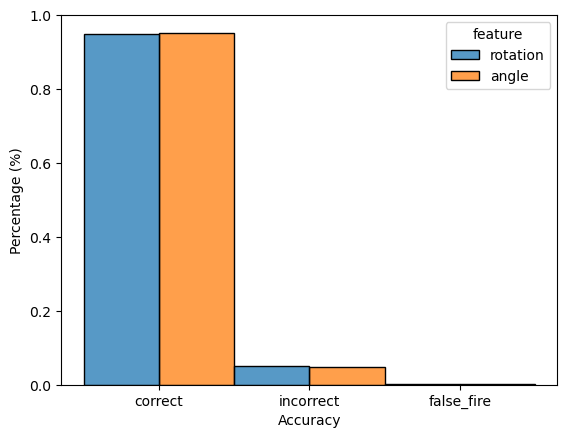

In [7]:
# Create the plot
sns.histplot(data=targets_df, x='accuracy', hue='feature', stat='proportion',common_norm = False, multiple='dodge')

plt.xlabel('Accuracy')
plt.ylabel('Percentage (%)')
plt.show()

In [8]:
# function for the calculation of SDT measures
# Otherwise, infer signal/noise from accuracy:
sub_df['is_signal'] = sub_df['accuracy'].isin(['correct', 'incorrect','too_slow'])  # Assume hits/misses = signal trials
sub_df['is_noise'] = sub_df['accuracy'].isin(['false_fire', 'correct_nogo'])

def calculate_dprime(group):
    # Calculate Hit Rate (HR)
    hits = (group['accuracy'] == 'correct').sum()
    signal_trials = group['is_signal'].sum()
    hr = (hits + 0.5) / (signal_trials + 1)
    acc = hits / signal_trials
    norm_hr = stats.norm.ppf(hr)

    # Calculate False Alarm Rate (FAR)
    false_alarms = (group['accuracy'] == 'false_fire').sum()
    noise_trials = group['is_noise'].sum()
    far = (false_alarms + 0.5) / (noise_trials +1)
    norm_far = stats.norm.ppf(far)
    
    # Calculate d' (Z-scores) and beta 
    dprime = norm_hr - norm_far
    beta = np.exp((norm_far**2 - norm_hr**2) / 2)

    return pd.Series({
        'hits': hits,
        'misses': (group['accuracy'] == 'incorrect').sum(),
        'too_slow': (group['accuracy'] == 'too_slow').sum(),
        'false_alarms': false_alarms,
        'signal_trials': signal_trials,
        'noise_trials': noise_trials,
        'hit_rate': hr,
        'accuracy': acc,
        'false_alarm_rate': far,
        'dprime': dprime,
        'beta':beta
    })


C:\Users\mvmigem\AppData\Local\Temp\ipykernel_17844\3924118770.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub_df['is_signal'] = sub_df['accuracy'].isin(['correct', 'incorrect','too_slow'])  # Assume hits/misses = signal trials
C:\Users\mvmigem\AppData\Local\Temp\ipykernel_17844\3924118770.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub_df['is_noise'] = sub_df['accuracy'].isin(['false_fire', 'correct_nogo'])


In [9]:
# function for the calculation of SDT measures
# Otherwise, infer signal/noise from accuracy:
targets_df['is_signal'] = sub_df['attended_feature'].isin(['regular'])  # Assume hits/misses = signal trials
targets_df['is_noise'] = sub_df['attended_feature'].isin(['odd'])


def calculate_other_dprime(group):
    # Calculate Hit Rate (HR)
    signal_group = group[group['is_signal']]
    hits = (signal_group['accuracy'] == 'correct').sum()
    signal_trials = group['is_signal'].sum()
    hr = (hits + 0.5) / (signal_trials + 1)
    acc = hits / signal_trials
    norm_hr = stats.norm.ppf(hr)

    # Calculate False Alarm Rate (FAR)
    noise_group = group[group['is_noise']]
    false_alarms = (noise_group['accuracy'] == 'incorrect').sum()
    noise_trials = group['is_noise'].sum()
    far = (false_alarms + 0.5) / (noise_trials +1)
    norm_far = stats.norm.ppf(far)
    
    # Calculate d' (Z-scores) and beta 
    dprime = norm_hr - norm_far
    beta = np.exp((norm_far**2 - norm_hr**2) / 2)

    return pd.Series({
        'hits': hits,
        'misses': (group['accuracy'] == 'incorrect').sum(),
        'too_slow': (group['accuracy'] == 'too_slow').sum(),
        'false_alarms': false_alarms,
        'signal_trials': signal_trials,
        'noise_trials': noise_trials,
        'hit_rate': hr,
        'accuracy': acc,
        'false_alarm_rate': far,
        'dprime': dprime,
        'beta':beta
    })

In [10]:
# Remove participants that have accuracy lower than 3std below mean
acc_results = sub_df.groupby(['participant']).apply(calculate_dprime).reset_index()
threshold = acc_results.accuracy.mean() - acc_results.accuracy.std() *3
ex_pp = acc_results[acc_results['accuracy'] <= threshold]['participant'].to_numpy()
sub_df = sub_df[~sub_df['participant'].isin(ex_pp)]
targets_df = targets_df[~targets_df['participant'].isin(ex_pp)]

C:\Users\mvmigem\AppData\Local\Temp\ipykernel_17844\1604200356.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  acc_results = sub_df.groupby(['participant']).apply(calculate_dprime).reset_index()


In [11]:
# Subselecting on particpant, block and task for the exclusion of 'practice' blocks
# Group by participant and condition, then apply d' calculation
acc_results = sub_df.groupby(['participant','block','feature']).apply(calculate_dprime).reset_index()
# Find the first blocks with an acc above chance level (.75) per task per participant
def filter_first_accurate_blocks(df, accuracy_threshold=0.75):
    """
    Filter blocks to find the first block for each task per participant 
    that meets the accuracy threshold
    """
    # Sort by participant, task, and block to ensure proper ordering
    df_sorted = df.sort_values(['participant', 'feature', 'block'])
    
    # Create a result dataframe
    result_rows = []
    invalid_rows = []
    # Group by participant and task
    for (participant, task), group in df_sorted.groupby(['participant', 'feature']):
        # Filter blocks for this participant-task combination
        task_blocks = group.sort_values('block')
        
        # Find the first block with accuracy >= threshold
        first_valid_block = None
        for _, row in task_blocks.iterrows():
            if row['accuracy'] > accuracy_threshold:
                first_valid_block = row
                break
            else:
                invalid_rows.append(row)
        
        # If found, add to results
        if first_valid_block is not None:
            result_rows.append(first_valid_block)

    
    # Create the filtered dataframe
    result_df = pd.DataFrame(result_rows)
    invalid_df = pd.DataFrame(invalid_rows)
    
    return result_df,invalid_df


valid_df,invalid_df = filter_first_accurate_blocks(acc_results)

C:\Users\mvmigem\AppData\Local\Temp\ipykernel_17844\1096610361.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  acc_results = sub_df.groupby(['participant','block','feature']).apply(calculate_dprime).reset_index()


In [12]:
excluded_blocks_df = invalid_df[['participant','block']]
excluded_blocks_df.to_csv('C:/Users/mvmigem/Documents/data/project_2/excluded_blocks.csv')

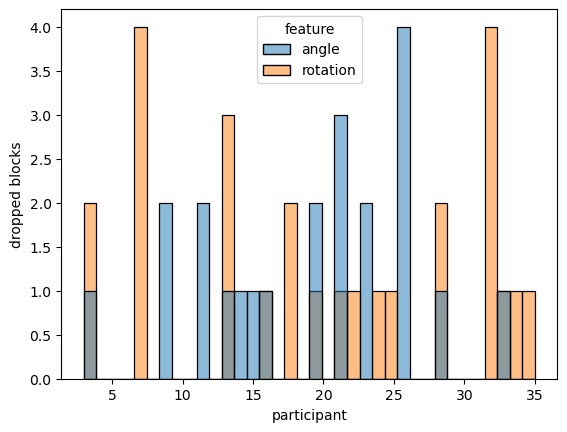

In [13]:
# Create the plot
sns.histplot(data=invalid_df, x='participant', hue= 'feature', stat='count',common_norm = False, bins = 36)
# sns.histplot(data=invalid_df, x='participant', stat='count',common_norm = False, bins = 36)
# plt.xlabel('')
plt.ylabel('dropped blocks')
plt.show()

In [14]:
# These dataframes give an overview of the the amount of excluded blocks
# task_participant_counts = invalid_df.groupby(['task']).size().reset_index(name='count')
task_participant_counts = invalid_df.groupby(['participant','feature']).size().reset_index(name='count')

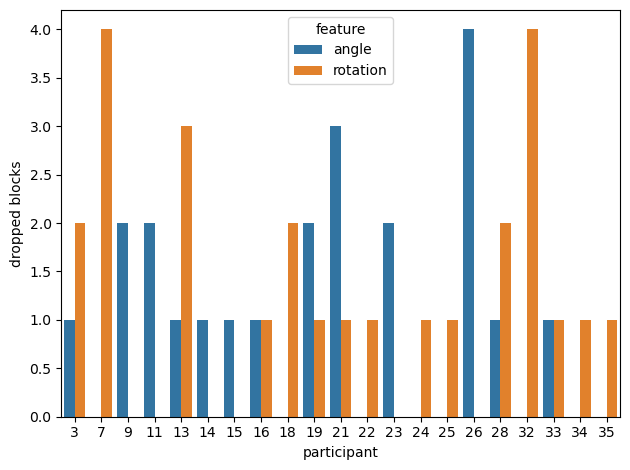

In [15]:
ax = sns.barplot(data=task_participant_counts, y = 'count', x = 'participant',hue= 'feature')
plt.ylabel('dropped blocks')
plt.tight_layout()
plt.show()

In [16]:
# Actually exclude
cutoff_list = list(zip(invalid_df['participant'],invalid_df['block']))
cuttoff_df = sub_df[~sub_df.set_index(['participant', 'block']).index.isin(cutoff_list)]

# acc_results = cuttoff_df.groupby(['participant','feature','unattended_feature']).apply(calculate_dprime).reset_index()
acc_results = cuttoff_df.groupby(['participant','feature','attended_feature','unattended_feature']).apply(calculate_dprime).reset_index()

C:\Users\mvmigem\AppData\Local\Temp\ipykernel_17844\3322780496.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  acc_results = cuttoff_df.groupby(['participant','feature','attended_feature','unattended_feature']).apply(calculate_dprime).reset_index()


In [21]:
# other dprime
cutoff_list = list(zip(invalid_df['participant'],invalid_df['block']))
cuttoff_df = targets_df[~targets_df.set_index(['participant', 'block']).index.isin(cutoff_list)]

acc_results = cuttoff_df.groupby(['participant','feature','unattended_feature']).apply(calculate_other_dprime).reset_index()
# acc_results = cuttoff_df.groupby(['participant','visual_field','feature','attended_feature','unattended_feature']).apply(calculate_dprime).reset_index()

C:\Users\mvmigem\AppData\Local\Temp\ipykernel_17844\4117320034.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  acc_results = cuttoff_df.groupby(['participant','feature','unattended_feature']).apply(calculate_other_dprime).reset_index()


In [22]:
cuttoff_df['acc_01'] = np.where(cuttoff_df['accuracy'] == 'correct', 1, 0)

C:\Users\mvmigem\AppData\Local\Temp\ipykernel_17844\323120813.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cuttoff_df['acc_01'] = np.where(cuttoff_df['accuracy'] == 'correct', 1, 0)


In [23]:
# Save the behaviour dataframe
destination_folder = r"C:\Users\mvmigem\Documents\data\project_2\compiled_data/"
acc_results.to_csv(destination_folder + "behaviour_acc.csv")
cuttoff_df.to_csv(destination_folder + "behaviour_acc_trials.csv")

C:\Users\mvmigem\AppData\Local\Temp\ipykernel_8608\3924118770.py:11: RuntimeWarning: divide by zero encountered in scalar divide
  acc = hits / signal_trials
C:\Users\mvmigem\AppData\Local\Temp\ipykernel_8608\680783590.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  acc_results = cuttoff_df.groupby(['participant','feature','attended_feature','unattended_feature']).apply(calculate_dprime).reset_index()


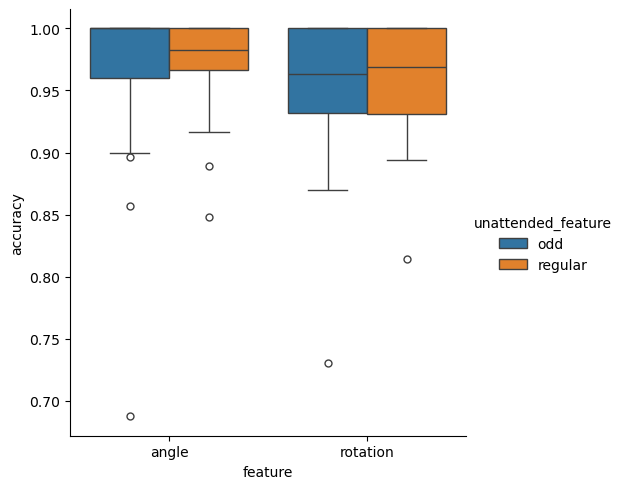

In [14]:
# Simple plots
# fig, axs = plt.subplots(1,2,figsize=(10, 4))
line_colours1= ['#219EBC','#FFB703']
line_colours2 = ['#8ECAE6','#FB8500',]

acc_results = cuttoff_df.groupby(['participant','feature','attended_feature','unattended_feature']).apply(calculate_dprime).reset_index()
sns.catplot(data= acc_results, y = 'accuracy', x = 'feature', hue='unattended_feature', kind= 'box')

plt.show()

In [ ]:
sns.set_style('whitegrid')
sns.set_context("talk")
acc_results = cuttoff_df.groupby(['participant','feature','unattended_feature']).apply(calculate_other_dprime).reset_index()

line_colours1= ['#219EBC','#FFB703','#8ECAE6','#FB8500',]

g = sns.catplot(data= acc_results, y = 'accuracy', x = 'feature',
            hue = 'unattended_feature',
            kind = 'bar',
            edgecolor= 'black',
            errorbar='se',
            linewidth=0.7, 
            order= ['angle', 'rotation'],
            hue_order= ['regular', 'odd'],
            palette=line_colours1)
# g.set(ylim= .7)
g.set_titles(fontdict={'family': 'Segoe UI', 'weight': 'bold', 'size': 14})
g.set_xlabels('Feature',fontdict={'family': 'Segoe UI', 'weight': 'semibold','size':16})
g.set_ylabels('Sensitivity (d\')',fontdict={'family': 'Segoe UI', 'weight': 'semibold','size':16})
g._legend.set_title('Unattend feature')
plt.setp(g._legend.get_title(), fontfamily='Segoe UI', fontweight='semibold', fontsize=14)
plt.setp(g._legend.get_texts(), fontfamily='Segoe UI', fontsize=14)

plt.show()

In [ ]:
# Save the behaviour dataframe
destination_folder = r"C:\Users\mvmigem\Documents\data\project_2\compiled_data/"
acc_results.to_csv(destination_folder + "behaviour_dprime.csv")

C:\Users\mvmigem\AppData\Local\Temp\ipykernel_20972\1089937235.py:5: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  g = sns.catplot(data= acc_results, y = 'accuracy', x = 'attended_feature',


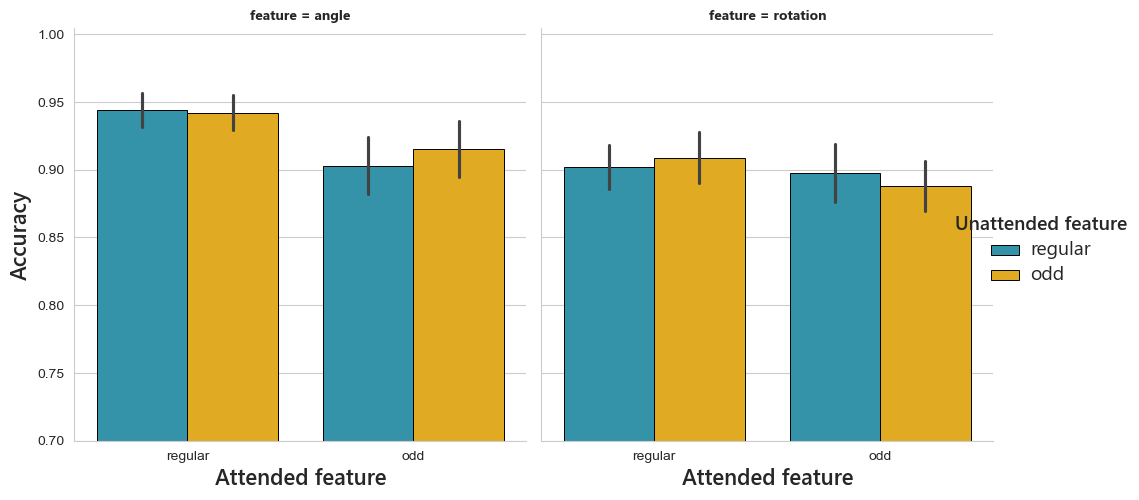

In [8]:
sns.set_style('whitegrid')

line_colours1= ['#219EBC','#FFB703','#8ECAE6','#FB8500',]

g = sns.catplot(data= acc_results, y = 'accuracy', x = 'attended_feature',
            hue = 'unattended_feature', col = 'feature',
            kind = 'bar',
            edgecolor= 'black',
            errorbar='se',
            linewidth=0.7, 
            hue_order= ['regular', 'odd'],
            order= ['regular', 'odd'],
            palette=line_colours1)
g.set(ylim= .7)
g.set_titles(fontdict={'family': 'Segoe UI', 'weight': 'bold', 'size': 14})
g.set_xlabels('Attended feature',fontdict={'family': 'Segoe UI', 'weight': 'semibold','size':16})
g.set_ylabels('Accuracy',fontdict={'family': 'Segoe UI', 'weight': 'semibold','size':16})
g._legend.set_title('Unattended feature')
plt.setp(g._legend.get_title(), fontfamily='Segoe UI', fontweight='semibold', fontsize=14)
plt.setp(g._legend.get_texts(), fontfamily='Segoe UI', fontsize=14)


plt.show()

In [17]:
"""
Reaction times
"""
# Only correct trials
rt_df = targets_df[targets_df['accuracy'].isin(['correct','too_slow'])]
# Start with group level participant exclusion (difference of more than 3 std fromn mean)
rt_results = rt_df.groupby(['participant'])['rt'].mean().reset_index()
grand_mean_rt = rt_results['rt'].mean()
three_std = 3 * rt_results['rt'].std()
rt_ex_pp = rt_results[~rt_results['rt'].between(grand_mean_rt - three_std, grand_mean_rt + three_std)]['participant'].values # Turns out none were excluded
# Apply
rt_df = rt_df[~rt_df['participant'].isin(rt_ex_pp)]

In [19]:
# Next the exclusion of within participant outlier trials
rt_results = rt_df.groupby(['participant'])['rt'].agg(['mean','std']).reset_index()
# Merge stats back to original DataFrame
rt_df = rt_df.merge(rt_results, on='participant')
# Filter trials within 3 standard deviations
outlier_mask = (
    (rt_df['rt'] >= rt_df['mean'] - 3 * rt_df['std']) &
    (rt_df['rt'] <= rt_df['mean'] + 3 * rt_df['std'])
)
# Count outliers per subject
trials_removed = rt_df[~outlier_mask].groupby('participant').size().rename('trials_removed')
# Apply
rt_df = rt_df[outlier_mask]


In [ ]:
# Create rt dataset
# rt_results = rt_df.groupby(['participant','feature','attended_feature','unattended_feature'])['rt'].mean().reset_index()
rt_results = rt_df.groupby(['participant','visual_field','feature','attended_feature','unattended_feature'])['rt'].mean().reset_index()

In [20]:
# Save the behaviour dataframe
destination_folder = r"C:\Users\mvmigem\Documents\data\project_2\compiled_data/"
# rt_results.to_csv(destination_folder + "behaviour_rt.csv")
rt_df.to_csv(destination_folder + "behaviour_rt_trial.csv")

In [ ]:
sns.set_style('whitegrid')

line_colours1= ['#219EBC','#FFB703','#8ECAE6','#FB8500',]

g = sns.catplot(data= rt_results, y = 'rt', x = 'attended_feature',
            hue = 'unattended_feature', col = 'feature',
            kind = 'bar',
            edgecolor= 'black',
            errorbar='se',
            linewidth=0.7,
            hue_order= ['regular', 'odd'],
            order= ['regular', 'odd'],
            palette=line_colours1)
# g.set(ylim= .7)
g.set_titles(fontdict={'family': 'Segoe UI', 'weight': 'bold', 'size': 14})
g.set_xlabels('Attended feature',fontdict={'family': 'Segoe UI', 'weight': 'semibold','size':16})
g.set_ylabels('Reaction Time',fontdict={'family': 'Segoe UI', 'weight': 'semibold','size':16})
g._legend.set_title('Unattended feature')
plt.setp(g._legend.get_title(), fontfamily='Segoe UI', fontweight='semibold', fontsize=14)
plt.setp(g._legend.get_texts(), fontfamily='Segoe UI', fontsize=14)
plt.show()

In [ ]:
# Demographics
demo_df = big_df[big_df['trial'] == 1][big_df['sequence'] == 1]

In [ ]:
demo_df['handed'].value_counts()

In [ ]:
demo_df['age'].agg(['mean','std'])

In [ ]:
check_df = big_df[~big_df.set_index(['participant', 'block']).index.isin(cutoff_list)]

In [ ]:
"""
Counting the amount of events
"""
sub_list = big_df['participant'].unique() 
# Step 1: Group by subject, attention, and expectation, and count rows
# df_to_count = big_df[~(big_df['participant'].isin([]))]
# df_to_count = big_df[~(big_df['participant'].isin([27,31,33]))]
df_to_count = check_df[~(check_df.participant.isin([27,31,33]))]
# df_to_count = check_df[~(check_df.participant.isin([27,31,33]))]
# grouped = df_to_count.groupby(['participant', 'feature','attended_feature','unattended_feature']).size().reset_index(name='row_count')
# grouped = event_df.groupby(['subject', 'feature','attended_feature','unattended_feature']).size().reset_index(name='row_count')
grouped = event_df[event_df['sequence']==2].groupby(['subject', 'feature','attended_feature','unattended_feature']).size().reset_index(name='row_count')
# grouped = grouped[~(grouped['participant'].isin([27,31,33]))]

# Step 3: Group by attention and expectation, and calculate the mean and standard deviation
stats_per_condition = grouped.groupby(['feature','attended_feature','unattended_feature'])['row_count'].agg(['mean', 'std']).reset_index()
# stats_per_condition = grouped.groupby(['angle_prediction'])['row_count'].agg(['mean', 'std']).reset_index()


In [ ]:
# Preprocessed events for indication of events after artifact rejection
events_path = 'C:/Users/mvmigem/Documents/data/project_2/preprocessed/mastoid-raw-csv/512Hz/events/'
dir_list = glob.glob(events_path+"*.csv")

df_list = []
for i in range(len(dir_list)):
    behav_dat = pd.read_csv(dir_list[i])
    df_list.append(behav_dat)

event_df = pd.concat(df_list,ignore_index=True)
event_df = event_df[~event_df['event_codes'].isin([99])]